# Extract trace element values per specimen and provide a data overview

Author: **Niels J. de Winter** (*n.j.de.winter@vu.nl*)<br>
Assistant Professor Vrije Universiteit Amsterdam

In [1]:
# Load functions and libraries
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter
import seaborn as sns
import matplotlib.pyplot as plt

## Extract data summary and specimen names

In [2]:
# Load All data summary to extract specimen names for subsetting
data_summary = pd.read_csv("All_data_summary.csv")
# Extract unique specimen names from the summary data and combine with first 3 letters of treatment information to create a unique identifier for each specimen
specimen_names = np.unique(data_summary['specimen'].astype(str) + '_' + data_summary['treatment'].str[:3])
print(specimen_names)

['B255_int' 'B323_int' 'B325_int' 'G652_sub' 'G664_sub' 'G668_sub'
 'G691_int' 'G717_sub' 'G719_int' 'G723_sub' 'G728_int' 'G730_sub'
 'G732_sub' 'G737_sub' 'G753_sub' 'G767_sub' 'G770_sub' 'G779_int'
 'G781_sub']


## Plot elemental means and standard deviations per specimen per interval

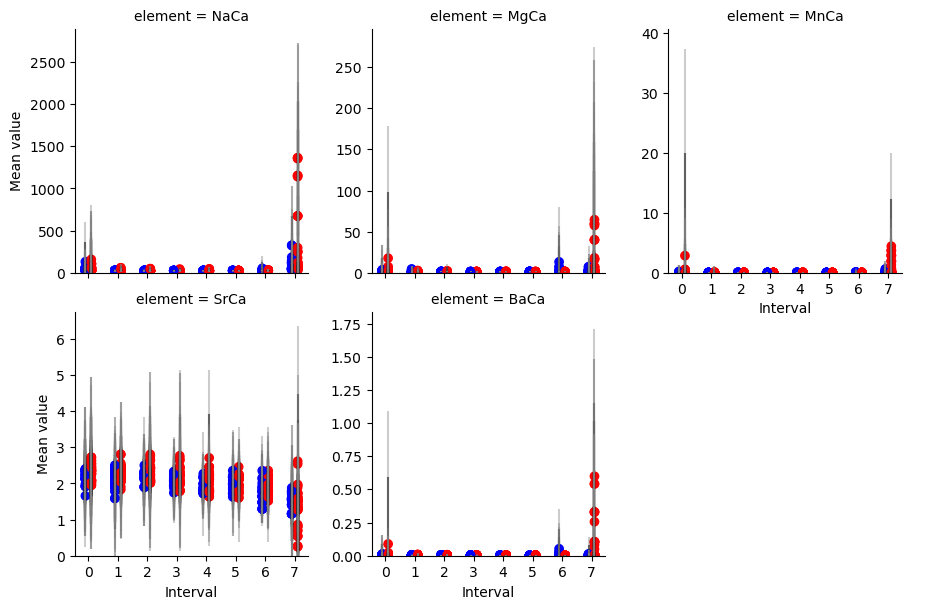

In [15]:
elements = ['NaCa','MgCa','MnCa','SrCa','BaCa']

# Build long dataframe
long_data_summary = pd.concat([
    data_summary[['specimen','Interval','treatment',
        f'{el}_mean', f'{el}_sd']].rename(
        columns={f'{el}_mean':'mean', f'{el}_sd':'sd'}
    ).assign(element=el)
    for el in elements
])

long_data_summary = long_data_summary[
    long_data_summary['Interval'].str.startswith('interval', na=False)
]

# Create numeric positions
long_data_summary['Interval_num'] = (
    long_data_summary['Interval']
    .astype('category')
    .cat.codes
)

g = sns.FacetGrid(long_data_summary, col="element", col_wrap=3, sharey=False)

def plot_with_errorbars(data, color, **kwargs):

    offset = data['treatment'].map({'intertidal': -0.1, 'subtidal': 0.1})

    x = data['Interval_num'] + offset
    y = data['mean']
    sd = data['sd']
    
    # plot mean points
    plt.scatter(x, y, c=data['treatment'].map({'intertidal':'blue','subtidal':'red'}))
    
    # ±1 SD
    plt.errorbar(x, y, yerr=sd, fmt='none', ecolor='black', alpha=0.7)
    
    # ±2 SD
    plt.errorbar(x, y, yerr=2*sd, fmt='none', ecolor='gray', alpha=0.4)

g.map_dataframe(plot_with_errorbars)

# Set y-axis labels from elements vector
for ax, el in zip(g.axes.flat, elements):
    ax.set_ylabel(el)

for ax in g.axes.flat:
    ax.set_xticks(range(0, 8))  # ticks at 0,1,...,7

g.set(ylim=(0, None))
g.add_legend()
g.set_axis_labels("Interval", "Mean value")

plt.show()

## Loop through files and extract information about uncertainty using duplicate analyses

In [4]:
# Create dataframe for storing information about reproduciblity per specimen and per element
reproducibility_df = pd.DataFrame(columns=['specimen', 'element', 'combined_std_dev'])

# List of elements to analyze
elements = ['23Na/43Ca', '25Mg/43Ca', '55Mn/43Ca', '88Sr/43Ca', '138Ba/43Ca']

for specimen in specimen_names:
    dat = pd.read_csv(specimen + '.csv') # Load the data for the current specimen
    dat = dat[1:].reset_index(drop=True) # remove top row that contains string values instead of numeric values
    dat = dat.apply(pd.to_numeric, errors='coerce') # convert all columns to numeric values, coercing errors to NaN
    unique_x, indices, counts = np.unique(dat['depth'], return_inverse = True, return_counts = True) # Find unique x-values and their indices
    print(f'{len(dat["depth"]) - len(unique_x)} duplicates were identified in specimen {specimen}')

    # Loop through each element and calculate the combined standard deviation for the duplicates
    for element in elements:
        element_data = dat[element].copy()  # Assuming the proxy values are in the specified columns
        # Convert zeroes to NaN to avoid skewing the standard deviation calculation
        element_data[element_data == 0] = np.nan
        # Smooth data to the size of the laser spot (20 um in scanning direction, so window of approximately 45 data points; 20 um / 0.44 um per data point = ~45)
        element_data = savgol_filter(element_data, window_length=45, polyorder=2, mode='nearest')  # Apply Savitzky-Golay filter for smoothing
        # Calculate the mean uncertainty (standard deviation) based on the duplicates
        std_devs = np.zeros(len(unique_x))
        for i in range(len(unique_x)):
            duplicate_indices = np.where(indices == i)[0]
            if len(duplicate_indices) > 1:
                std_devs[i] = np.std(element_data[duplicate_indices])  # Calculate standard deviation for duplicates

        # Calculate the combined standard deviation
        combined_variance = np.sum(std_devs[std_devs > 0]**2)  # Sum of variances
        combined_std_dev = np.sqrt(combined_variance / np.sum(counts > 1))  # Combined standard deviation
        print(f'Combined standard deviation of element {element} in specimen {specimen} from duplicates: {combined_std_dev:.3g} mmol/mol')
        reproducibility_df.loc[len(reproducibility_df)] = {
            'specimen': specimen,
            'element': element,
            'combined_std_dev': combined_std_dev
        }
# Save the reproducibility results to a CSV file
print(reproducibility_df.head())
reproducibility_df.to_csv('TE_duplicate_reproducibility_results.csv', index=False)

156 duplicates were identified in specimen B255_int
Combined standard deviation of element 23Na/43Ca in specimen B255_int from duplicates: 0.318 mmol/mol
Combined standard deviation of element 25Mg/43Ca in specimen B255_int from duplicates: 0.0106 mmol/mol
Combined standard deviation of element 55Mn/43Ca in specimen B255_int from duplicates: 9.83e-05 mmol/mol
Combined standard deviation of element 88Sr/43Ca in specimen B255_int from duplicates: 0.0369 mmol/mol
Combined standard deviation of element 138Ba/43Ca in specimen B255_int from duplicates: 5.29e-05 mmol/mol
115 duplicates were identified in specimen B323_int
Combined standard deviation of element 23Na/43Ca in specimen B323_int from duplicates: 0.53 mmol/mol
Combined standard deviation of element 25Mg/43Ca in specimen B323_int from duplicates: 0.0906 mmol/mol
Combined standard deviation of element 55Mn/43Ca in specimen B323_int from duplicates: 0.000707 mmol/mol
Combined standard deviation of element 88Sr/43Ca in specimen B323_in